In [43]:
import pandas as pd
import re
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *
import numpy as np

In [44]:
df = pd.read_excel(VALIDATION_SAMPLE)

## Technologies

In [45]:
def find_language_robust(tags_text, target_languages):
    """
    Check if any target language is present in the tags string using a robust
    regex that handles special characters like '+' and '#'.

    Returns the matched language (original capitalization) or 'n/a' if none found.
    """
    if pd.isna(tags_text) or not tags_text.strip():
        return 'n/a'

    tags_text_lower = tags_text.lower()

    for lang in target_languages:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)

        regex_search = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'

        if re.search(regex_search, tags_text_lower):
            return lang

    return 'n/a'


LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Obj-C', 'Go',
              'Perl', 'Ruby', 'Delphi', 'Powershell', 'SQL', 'TSQL', 'Vbnet', 'Lisp', 'Lua', 'Bash',
              'R', 'Haskell', 'Matlab', 'Rust']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

# Apply language detection
df['language'] = df['technologies'].str.lower().apply(lambda x: find_language_robust(x, LANGUAGES))

In [46]:
language_percentages = df['language'].value_counts() / df.shape[0] * 100
language_percentages

language
n/a           58.028169
Java           9.014085
PHP            7.605634
Python         7.605634
C#             6.197183
C++            3.661972
Bash           1.408451
C              1.408451
Rust           0.845070
JavaScript     0.845070
Ruby           0.845070
Go             0.563380
SQL            0.563380
Lua            0.281690
Matlab         0.281690
Haskell        0.281690
R              0.281690
Powershell     0.281690
Name: count, dtype: float64

In [47]:
language_percentages = language_percentages.drop('n/a', errors='ignore')

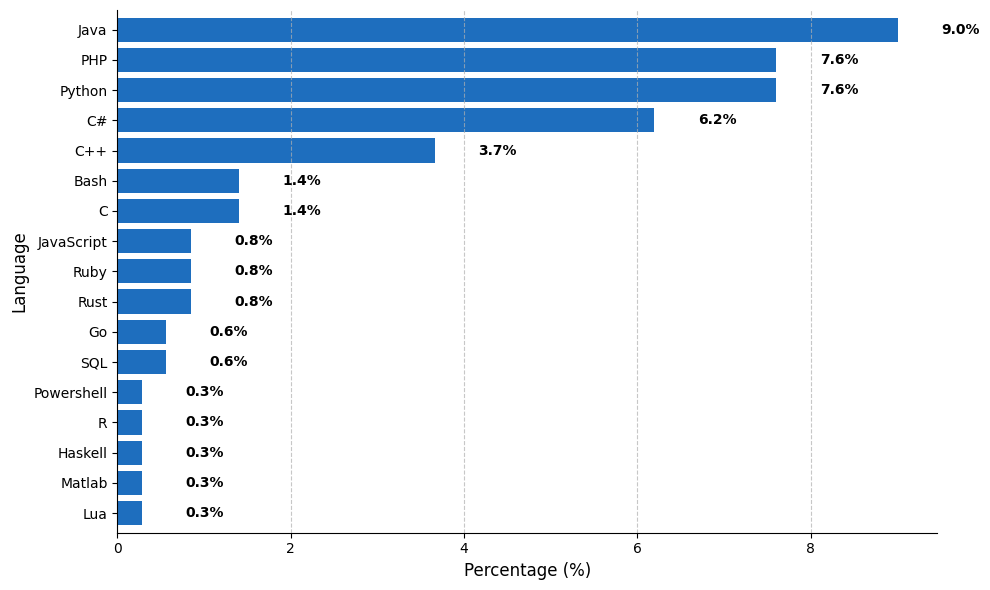

In [48]:
import matplotlib.pyplot as plt

language_percentages = language_percentages.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = language_percentages.plot.barh(color="#1e6ebe", width=0.8)

#plt.title('Programming Languages Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Language', fontsize=12)

for i, v in enumerate(language_percentages):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)   
ax.spines['right'].set_visible(False) 
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(LANGUAGES_DISTRIBUTION, dpi=600, bbox_inches='tight')
plt.show()


In [49]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove the specified languages from the technologies string.
    Returns 'n/a' if the resulting list is empty or input is missing.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'n/a'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    return ', '.join(filtered_list) if filtered_list else 'n/a'


# Apply language removal to create a cleaned technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [50]:
def normalize_technology_terms(cell: str) -> str:
    """Normalize technology terms to canonical short forms."""
    if not isinstance(cell, str):
        return cell

    normalization_map = {
        "aes-128": "aes",
        "aes-256": "aes",
        "rijndael": "aes",
        "aes-ni": "aes",

        "pkcs1": "pkcs",
        "pkcs#1": "pkcs",
        "pkcs5": "pkcs",
        "pkcs#5": "pkcs",
        "pkcs7": "pkcs",
        "pkcs#7": "pkcs",
        "pkcs11": "pkcs",
        "pkcs11.net": "pkcs",
        "pkcs11interop": "pkcs",
        "pkcs12": "pkcs",
        "pkcs#12": "pkcs",

        "sha1": "sha1",
        "sha-1": "sha1",
        "sha256": "sha",
        "sha-256": "sha",
        "sha512": "sha",
        "sha-512": "sha",
        "sha2": "sha",
    }

    normalized_terms = []

    for term in cell.split(","):
        t = term.strip().lower()
        t = re.sub(r"\s+", " ", t)
        normalized_terms.append(normalization_map.get(t, t))

    return ", ".join(normalized_terms)


# Apply normalization to cleaned technologies
df['technologies_clean'] = df['technologies_clean'].apply(normalize_technology_terms)

In [51]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)
clean_word_counts = exploded.value_counts()

In [52]:
len(exploded.unique())  # Total unique techs n - 1 | dont count with n/a

190

In [53]:
pd.set_option('display.max_rows', None)
clean_word_counts / df.shape[0] * 100

technologies_clean
openssl                  20.563380
aes                      16.056338
sha                      13.521127
md5                      10.704225
rsa                      10.140845
n/a                       8.450704
ssl                       8.169014
pkcs                      5.915493
.net                      5.352113
hash                      4.225352
base64                    4.225352
sha1                      3.943662
iv                        3.943662
tls                       3.380282
xor                       3.380282
cbc                       3.098592
bcrypt                    2.816901
pgp                       2.535211
mysql                     1.690141
ctr                       1.408451
ssh                       1.408451
bouncycastle              1.408451
ecb                       1.408451
pbkdf                     1.408451
node.js                   1.126761
gpg                       1.126761
truecrypt                 1.126761
mac                       1.126761
g

## Technologies Along Topics


In [54]:
# Same numbers as the table of RQ1 in article
topic_names = {
    "01": "OpenSSL installation/build and runtime errors",
    "02": "Encoding and byte/string conversions (Base64, binary)",
    "03": "X.509 certificates, signing, and trust chains",
    "04": "Password hashing with salt (bcrypt, rainbow tables)",
    "05": "Crypto library/API implementation in code",
    "06": "Number theory for crypto (primes, factoring, modular arithmetic)",
    "07": "Public-key cryptography: encryption and digital signatures",
    "08": "Block cipher modes, IV/nonce, and padding",
    "09": "Client-server secure communication (HTTP/HTTPS, sessions)",
    "10": "User authentication and account management",
    "11": "File handling, integrity checks & checksums",
    "12": "Security vs performance (cost, speed, hardware limits)",
    "13": "Password strength and entropy estimation",
    "14": "Secure random number generation (entropy, seeding, PRNG)",
    "15": "Cryptographic hash functions & collisions",
    "16": "Key sizes and security parameters selection",
    "17": "Key protection on devices (memory/disk access, threat model)",
    "18": "Application data encryption & key storage",
    "19": "Cryptosystem design pitfalls & attack resistance",
    "20": "Trust, vendors, and real-world security risk",
    "21": "Conceptual crypto explanations and learning",
}


# Manual selected terms. The percentages should be the same as the output of the previous cell    
crypto_technologies = {
    "Cryptographic Libraries": [
        "openssl (20.563380)",
        "crypto++ (0.845070)",
        "pycrypto (1.126761)",
        "libsodium (0.563380)",
        "mcrypt (0.563380)",
        "libtomcrypt (0.281690)",
        "pycryptopp (0.281690)",
        "as3crypto (0.281690)",
        "bouncycastle (1.408451)",
        "pyopenssl (0.845070)",
        "scrypt (0.845070)",
        "crypto-js (0.563380)",
        "itsdangerous (0.281690)",
        "keyczar (0.281690)",
        "pycryptodome (0.281690)",
        "python-cryptography (0.281690)",
        "libssl (0.845070)",
        "libcrypto (0.563380)"
    ],
    
    "Cryptography Algorithms": [
        "aes (16.056338)",
        "rsa (10.140845)",
        "sha (13.521127)",
        "md5 (10.704225)",
        "xor (3.380282)",
        "bcrypt (2.816901)",
        "des (0.563380)",
        "blowfish (0.281690)",
        "twofish (0.281690)",
        "serpent (0.281690)",
        "md2 (0.281690)",
        "arc4 (0.281690)",
        "rc4 (0.281690)",
        "paillier (0.281690)"
    ],
    
    "Hash Functions and HMAC": [
        "hash (4.225352)",
        "sha1 (3.943662)",
        "hmac (0.563380)",
        "hmacsha1 (0.563380)",
        "blake2bp (0.281690)"
    ],
    
    "Operation Modes": [
        "cbc (3.098592)",
        "ctr (1.408451)",
        "ecb (1.408451)",
        "gcm (1.126761)",
        "ofb (0.281690)",
        "cfb (0.281690)",
        "siv (0.281690)",
        "xex (0.563380)",
        "ocb2 (0.281690)"
    ],
    
    "Security Protocols": [
        "ssl (8.169014)",
        "tls (3.380282)",
        "ssh (1.408451)",
        "https (1.126761)",
        "vpn (0.563380)",
        "openvpn (0.563380)"
    ],
    
    "PKI and Certificates": [
        "pkcs (5.915493)",
        "x509 (0.845070)",
        "pgp (2.535211)",
        "gpg (1.126761)",
        "openpgp (0.563380)",
        "s/mime (0.281690)",
        "pki (0.281690)",
        "crl (0.281690)",
        "ssl ocsp (0.281690)"
    ],
    
    "Public-Key Cryptography": [
        "public-key (0.563380)",
        "ecdsa (0.563380)",
        "ecc (0.845070)",
        "diffie-hellman (0.563380)",
        "dh (0.281690)",
        "public-key-encryption (0.281690)"
    ],
    
    "Key Derivation and KDF": [
        "pbkdf (1.408451)",
        "pbkdf2 (0.563380)",
        "argon2 (0.845070)",
        "csprng (0.281690)",
        "node-scrypt (0.281690)"
    ],
    
    "Encoding and Utilities": [
        "base64 (4.225352)",
        "iv (3.943662)",
        "mac (1.126761)",
        "otp (0.563380)",
        "oaep (0.563380)",
        "rsa-oaep (0.281690)",
        "aad (0.281690)",
        "aead (0.281690)",
        "eme (0.281690)",
        "prp (0.281690)",
        "kcv (0.281690)",
        "key rotation (0.281690)"
    ],
    
    "Hardware and Security Modules": [
        "tpm (0.845070)",
        "hsm (0.281690)",
        "nitrokey (0.281690)",
        "smartcard-hsm (0.281690)",
        "ncryptoki (0.563380)",
        "trng (0.281690)",
        "kryptorfpga (0.281690)",
        "cryptechalpha (0.281690)"
    ],
    
    "Cryptography Tools": [
        "truecrypt (1.126761)",
        "veracrypt (0.281690)",
        "diceware (1.126761)",
        "zxcvbn (0.563380)",
        "keytool (0.845070)",
        "xca (0.281690)",
        "sqlcipher (0.281690)",
        "disk encryption (0.281690)",
        "luks (0.563380)",
        "steganography (0.563380)",
        "xsteg (0.281690)",
        "stegbreak (0.281690)"
    ],
    
    "Application Security": [
        "csrf (0.563380)",
        "cors (0.281690)",
        "oauth2 (0.281690)",
        "sso (0.281690)",
        "backdoors (0.281690)",
        "nsa (0.281690)",
        "webcrypto-api (0.281690)"
    ],
    
    "Platforms and Development Environments": [
        ".net (5.352113)",
        "asp.net (0.845070)",
        "node.js (1.126761)",
        "jce (0.563380)",
        "cryptoapi (0.563380)",
        "xamarin (0.563380)",
        "xcode (0.563380)",
        "django (0.563380)",
        "react native (0.281690)",
        "swift3 (0.281690)",
        "cordova (0.281690)",
        "javax (0.281690)",
        "firemonkey (0.281690)",
        "apk (0.281690)",
        "visual studio (0.281690)"
    ],
    
    "Concepts and Theoretical Models": [
        "block-cipher (0.563380)",
        "cpa-security (0.563380)",
        "cca (0.563380)",
        "m-cca2 (0.281690)",
        "rfc (0.281690)"
    ],
    
    "Other": [
        "mysql (1.690141)",
        "homebrew (0.845070)",
        "mongodb (0.281690)",
        "nginx (0.281690)",
        "cmake (0.563380)",
        "git (0.563380)",
        "docker (0.281690)",
        "aws (0.281690)",
        "udp (0.563380)",
        "http (0.563380)",
        "tcp (0.281690)",
        "smtp (0.281690)",
        "mingw (0.281690)",
        "gcc (0.281690)",
        "json (0.281690)",
        "pdf (0.281690)",
        "sqlite (0.281690)",
        "pandas (0.281690)",
        "gcp (0.281690)",
        "cloudflare (0.281690)",
        "sql server (0.281690)",
        "codeigniter (0.281690)",
        "struts2 (0.281690)",
        "typo3 (0.281690)",
        "xampp (0.281690)",
        "itext (0.281690)",
        "debian (0.281690)",
        "manjaro (0.281690)",
        "boto (0.281690)",
        "lts (0.281690)",
        "solana (0.281690)",
        "hdfs (0.281690)",
        "tar (0.281690)",
        "mplayer (0.281690)",
        "luabit (0.281690)",
        "bitlib (0.281690)",
        "libcurl (0.281690)",
        "libss (0.281690)",
        "gnutls (0.281690)",
        "xcb (0.281690)",
        "keychain (0.281690)",
        "orapki (0.281690)",
        "comodo (0.281690)",
        "signtool (0.281690)",
        "pfx (0.281690)",
        "savon (0.281690)",
        "dotpeek (0.281690)",
        ".net reflector (0.281690)",
        "agcd (0.281690)",
        "ecm (0.281690)",
        "tme (0.281690)",
        "feal-4 (0.281690)",
        "jizz-jazz (0.281690)",
        "xored (0.281690)",
        "cryptocode (0.281690)",
        "crypto5 (0.281690)",
        "pythoncrypter (0.281690)",
        "cryptopp562 (0.281690)",
        "n/a (8.450704)"
    ]
}


## Usage patterns

In [55]:
MIN_TOPICS_CROSS  = 4
MIN_PEAK_SPECIFIC = 8.0

def classify_tech(row_series: pd.Series, 
                  min_topics_cross: int = MIN_TOPICS_CROSS, 
                  min_peak_specific: float = MIN_PEAK_SPECIFIC) -> str:
    """
    Classifica uma tecnologia com base na sua distribuição entre tópicos.

    Parâmetros
    ----------
    row_series : pd.Series
        Série com as frequências (%) da tecnologia em cada tópico.
    min_topics_cross : int
        Número mínimo de tópicos com presença (> 0) para ser cross-cutting.
    min_peak_specific : float
        Frequência máxima mínima (%) para ser topic-specific.

    Retorna
    -------
    str : "cross-cutting" | "topic-specific" | "sparse"
    """
    non_zero = (row_series > 0).sum()
    max_freq  = row_series.max()

    if non_zero >= min_topics_cross:
        return "cross-cutting"
    if max_freq >= min_peak_specific:
        return "topic-specific"
    return "sparse"

In [56]:
from collections import defaultdict

def build_classification_table(
    tech_topic_counts: pd.DataFrame,
    crypto_technologies: dict,
    topic_names: dict,
    topic_ids_sorted: list,
    posts_per_topic: dict,
    omit_categories: set = None,
    min_topics_cross: int = MIN_TOPICS_CROSS,
    min_peak_specific: float = MIN_PEAK_SPECIFIC,
) -> pd.DataFrame:
    """
    Constrói um DataFrame com a contagem de tecnologias por tipo
    (cross-cutting, topic-specific, sparse) para cada categoria.
    """
    name_to_id = {v: k for k, v in topic_names.items()}
    tech_topic_counts = tech_topic_counts.copy()
    tech_topic_counts['topic_id'] = tech_topic_counts['topic'].map(name_to_id)

    rows = []
    totals = defaultdict(int)

    for categoria, tecnologias_com_pct in crypto_technologies.items():
        if omit_categories and categoria in omit_categories:
            continue

        tecnologias = [t.split(' (')[0].strip().lower() for t in tecnologias_com_pct]
        cat_data = tech_topic_counts[tech_topic_counts['tech'].isin(tecnologias)].copy()

        if cat_data.empty:
            rows.append({
                'Category': categoria,
                'Cross-cutting': 0,
                'Topic-specific': 0,
                'Sparse': 0,
            })
            continue

        pivot = (
            cat_data
            .pivot(index='tech', columns='topic_id', values='pct')
            .fillna(0)
            .reindex(columns=topic_ids_sorted, fill_value=0)
        )

        counts = defaultdict(int)
        for _, row in pivot.iterrows():
            label = classify_tech(row, min_topics_cross, min_peak_specific)
            counts[label] += 1

        cross    = counts['cross-cutting']
        specific = counts['topic-specific']
        sparse   = counts['sparse']

        totals['Cross-cutting'] += cross
        totals['Topic-specific'] += specific
        totals['Sparse'] += sparse

        rows.append({
            'Category': categoria,
            'Cross-cutting': cross,
            'Topic-specific': specific,
            'Sparse': sparse,
        })

    rows.append({
        'Category': 'Total',
        'Cross-cutting': totals['Cross-cutting'],
        'Topic-specific': totals['Topic-specific'],
        'Sparse': totals['Sparse'],
    })

    return pd.DataFrame(rows)


def print_classification_table(df_table: pd.DataFrame):
    """
    Imprime a tabela no formato textual semelhante ao artigo.
    """
    col_category = 'Category'
    cols_types   = ['Cross-cutting', 'Topic-specific', 'Sparse']

    # Larguras das colunas
    w_cat  = max(len(col_category), df_table[col_category].str.len().max()) + 2
    w_cols = {c: max(len(c), df_table[c].astype(str).str.len().max()) + 2 for c in cols_types}

    sep_thin = (
        '-' * w_cat
        + '  '
        + '  '.join('-' * w_cols[c] for c in cols_types)
    )
    sep_thick = (
        '=' * w_cat
        + '  '
        + '  '.join('=' * w_cols[c] for c in cols_types)
    )

    def fmt_row(cat, values: dict, bold=False):
        cat_str = cat.ljust(w_cat)
        vals    = '  '.join(str(values[c]).center(w_cols[c]) for c in cols_types)
        return f"{cat_str}  {vals}"

    # ── Header ────────────────────────────────────────────────────────────────
    header_cat  = col_category.ljust(w_cat)
    header_cols = '  '.join(c.center(w_cols[c]) for c in cols_types)
    print(f"\n{header_cat}  {header_cols}")
    print(sep_thin)

    # ── Rows ──────────────────────────────────────────────────────────────────
    total_row = df_table[df_table['Category'] == 'Total']
    body_rows = df_table[df_table['Category'] != 'Total']

    for _, row in body_rows.iterrows():
        print(fmt_row(row['Category'], row.to_dict()))

    # ── Total ─────────────────────────────────────────────────────────────────
    print(sep_thick)
    total = total_row.iloc[0]
    print(fmt_row(total['Category'], total.to_dict()))
    print()

In [57]:
# Compute necessary variables
tmp_df = df[['topic', 'technologies_clean']].copy()
tmp_df['post_id'] = tmp_df.index
tmp_df = tmp_df.assign(tech=tmp_df['technologies_clean'].str.split(',')).explode('tech')
tmp_df['tech'] = tmp_df['tech'].astype(str).str.strip().str.lower()
tmp_df['tech'] = (
    tmp_df['tech']
    .replace({'': 'n/a', 'nan': 'n/a', 'none': 'n/a'})
    .fillna('n/a')
)

posts_per_topic = df.groupby('topic').size().to_dict()

tech_topic_counts = (
    tmp_df
    .groupby(['tech', 'topic'])['post_id']
    .nunique()
    .reset_index(name='count')
)
tech_topic_counts['pct'] = tech_topic_counts.apply(
    lambda row: (row['count'] / posts_per_topic.get(row['topic'], 1)) * 100,
    axis=1,
)

name_to_id = {v: k for k, v in topic_names.items()}
tech_topic_counts['topic_id'] = tech_topic_counts['topic'].map(name_to_id)
topic_ids_sorted = [f"{i:02d}" for i in range(1, 22)]

df_table = build_classification_table(
    tech_topic_counts=tech_topic_counts,
    crypto_technologies=crypto_technologies,
    topic_names=topic_names,
    topic_ids_sorted=topic_ids_sorted,
    posts_per_topic=posts_per_topic,
)

print_classification_table(df_table)


Category                                   Cross-cutting    Topic-specific    Sparse 
----------------------------------------  ---------------  ----------------  --------
Cryptographic Libraries                          1                6             11   
Cryptography Algorithms                          6                3             5    
Hash Functions and HMAC                          1                3             1    
Operation Modes                                  0                6             3    
Security Protocols                               3                2             1    
PKI and Certificates                             2                3             4    
Public-Key Cryptography                          0                5             1    
Key Derivation and KDF                           0                4             1    
Encoding and Utilities                           1                4             7    
Hardware and Security Modules                    0   

In [58]:
import matplotlib.patches as mpatches

TYPE_LABELS = {
    'cross-cutting': 'Cross-cutting',
    'topic-specific': 'Topic-specific',
    'sparse': 'Sparse',
}

def plot_stacked_bar_classification(
    df_table: pd.DataFrame,
    type_colors: dict = None,
    type_labels: dict = TYPE_LABELS,
    figsize: tuple = (12, 6),
    output_path: str = None,
):
    BLUE_COLORS = {
        'cross-cutting':  '#1F3864',
        'topic-specific': '#2E75B6',
        'sparse':         '#BDD7EE',
    }
    if type_colors is None:
        type_colors = BLUE_COLORS

    TEXT_COLORS = {
        'cross-cutting':  'white',
        'topic-specific': 'white',
        'sparse':         '#1F3864',
    }

    cols_types = ['cross-cutting', 'topic-specific', 'sparse']
    MIN_HEIGHT_FOR_LABEL = 7  # % mínimo para caber texto dentro

    plot_df = df_table[df_table['Category'] != 'Total'].copy()
    plot_df.columns = [
        c.lower().replace(' ', '-') if c != 'Category' else c
        for c in plot_df.columns
    ]

    plot_df[cols_types] = plot_df[cols_types].apply(pd.to_numeric, errors='coerce').fillna(0)
    row_totals = plot_df[cols_types].sum(axis=1)
    pct_df = plot_df[cols_types].div(row_totals, axis=0) * 100

    categories = plot_df['Category'].tolist()
    n_cats = len(categories)
    x = np.arange(n_cats)

    fig, ax = plt.subplots(figsize=figsize)

    bottoms = np.zeros(n_cats)
    all_bars_info = []  # coleta tudo para anotar depois

    for col in cols_types:
        values = pct_df[col].to_numpy(dtype=float)
        bars = ax.bar(
            x, values,
            bottom=bottoms,
            color=type_colors[col],
            label=type_labels[col],
            edgecolor='none',
        )
        for i, (bar, pct_val) in enumerate(zip(bars, values)):
            if pct_val > 0:
                all_bars_info.append({
                    'bar': bar,
                    'pct_val': pct_val,
                    'col': col,
                    'cat_idx': i,
                })
        bottoms += values

    bar_width = all_bars_info[0]['bar'].get_width()

    # Categorias nas extremidades anotam para fora (esq/dir)
    # As do meio anotam dentro normalmente
    SIDE_MARGIN = 3  # quantas categorias das bordas recebem anotação lateral

    for info in all_bars_info:
        bar     = info['bar']
        pct_val = info['pct_val']
        col     = info['col']
        i       = info['cat_idx']
        bar_x   = bar.get_x() + bar.get_width() / 2
        y_center = bar.get_y() + bar.get_height() / 2

        is_left_edge  = i < SIDE_MARGIN
        is_right_edge = i >= n_cats - SIDE_MARGIN
        is_small      = pct_val < MIN_HEIGHT_FOR_LABEL

        if is_small and (is_left_edge or is_right_edge):
            # Anotação lateral com seta horizontal
            if is_left_edge:
                x_text  = bar.get_x() - bar_width * 0.3
                ha      = 'right'
            else:
                x_text  = bar.get_x() + bar_width * 1.3
                ha      = 'left'

            ax.annotate(
                f'{pct_val:.0f}%',
                xy=(bar_x, y_center),
                xytext=(x_text, y_center),
                ha=ha, va='center',
                fontsize=7.5, fontweight='bold',
                color=type_colors[col],
                arrowprops=dict(
                    arrowstyle='-',
                    color='gray',
                    lw=0.8,
                ),
            )
        elif is_small:
            # Segmento pequeno no meio: anota acima da barra
            ax.annotate(
                f'{pct_val:.0f}%',
                xy=(bar_x, bar.get_y() + bar.get_height()),
                xytext=(bar_x, 103),
                ha='center', va='bottom',
                fontsize=7.5, fontweight='bold',
                color=type_colors[col],
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
            )
        else:
            # Texto dentro do segmento
            ax.text(
                bar_x, y_center,
                f'{pct_val:.0f}%',
                ha='center', va='center',
                fontsize=8, fontweight='bold',
                color=TEXT_COLORS[col],
            )

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Percentage of Technologies (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Categories', fontsize=11, fontweight='bold')

    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%' if v <= 100 else ''))
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5, color='lightgray')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    patches = [
        mpatches.Patch(color=type_colors[t], label=type_labels[t])
        for t in cols_types
    ]
    ax.legend(
        handles=patches,
        loc='upper right',
        fontsize=9,
        frameon=True,
        framealpha=0.9,
        edgecolor='lightgray',
    )

    plt.tight_layout()

    fig.savefig(
        NOTEBOOK_OUTPUTS / 'rq3' / 'plots' / 'tech_distribution.pdf',
        dpi=300, bbox_inches='tight',
    )
    print(f"Saved: {output_path}")
    plt.show()

Saved: None


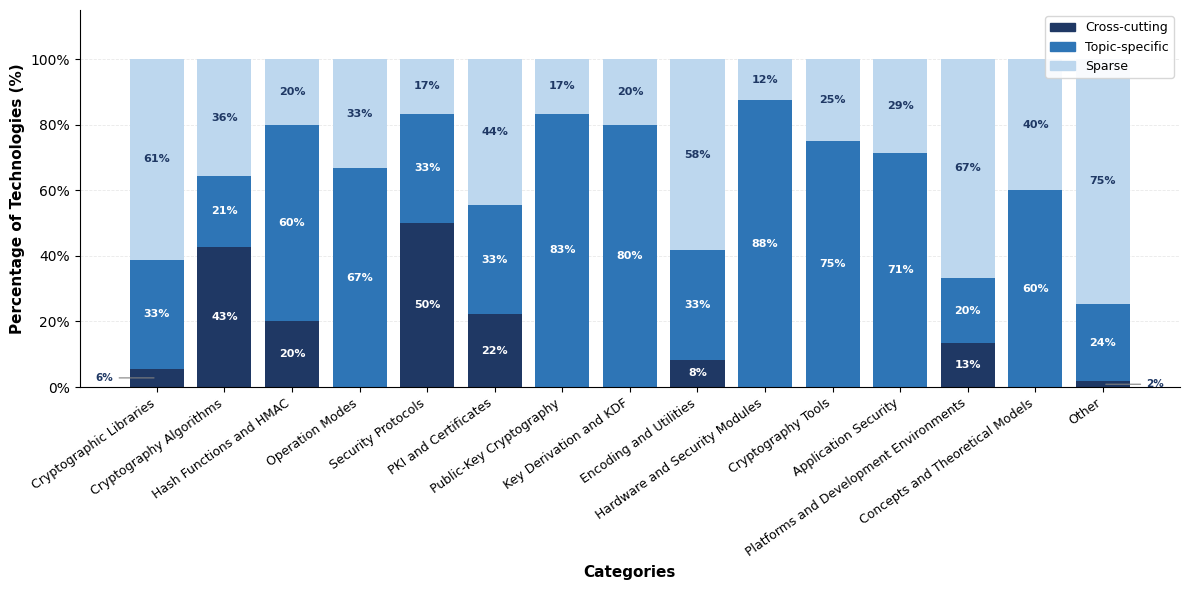

In [59]:
plot_stacked_bar_classification(df_table)

## Heatmaps

In [60]:
import seaborn as sns
import os

CELL_WIDTH = 0.2
CELL_HEIGHT = 0.12
OMIT_CATEGORIES = set()

CATEGORY_ABBREV = {
    "Cryptographic Libraries":               "LIB",
    "Cryptography Algorithms":               "ALG",
    "Hash Functions and HMAC":               "HSH",
    "Operation Modes":                       "MOD",
    "Security Protocols":                    "SEC",
    "PKI and Certificates":                  "PKI",
    "Public-Key Cryptography":               "PKY",
    "Key Derivation and KDF":                "KDF",
    "Encoding and Utilities":                "ENC",
    "Hardware and Security Modules":         "HSM",
    "Cryptography Tools":                    "TLS",
    "Application Security":                  "APP",
    "Platforms and Development Environments":"PLT",
    "Concepts and Theoretical Models":       "CNP",
    "Other":                                 "OTH",
}

PATTERN_CONFIG = {
    "cross-cutting":  {"label": "Cross-cutting",  "short": "CROSS", "color": "#185FA5", "cmap": "Blues",                              "vmin": 0,  "vmax": 80},
    "topic-specific": {"label": "Topic-specific", "short": "TOPIC", "color": "#3B6D11", "cmap": "Greens",                             "vmin": 0,  "vmax": 80},
    "sparse":         {"label": "Sparse",         "short": "SPARSE","color": "#555555", "cmap": sns.light_palette("#555555", as_cmap=True), "vmin": 0, "vmax": 15},
}

In [67]:
def generate_heatmap_by_pattern(
    target_type: str,
    omit_like_article: bool = False,
    figsize: tuple = None,
    short: bool = False,
):
    assert target_type in PATTERN_CONFIG, f"target_type deve ser um de {list(PATTERN_CONFIG)}"
    cfg = PATTERN_CONFIG[target_type]

    # ── 1. Pré-processamento ──────────────────────────────────────────────────
    tmp_df = df[['topic', 'technologies_clean']].copy()
    tmp_df['post_id'] = tmp_df.index
    tmp_df = tmp_df.assign(tech=tmp_df['technologies_clean'].str.split(',')).explode('tech')
    tmp_df['tech'] = tmp_df['tech'].astype(str).str.strip().str.lower()
    tmp_df['tech'] = (
        tmp_df['tech']
        .replace({'': 'n/a', 'nan': 'n/a', 'none': 'n/a'})
        .fillna('n/a')
    )

    posts_per_topic = df.groupby('topic').size().to_dict()

    tech_topic_counts = (
        tmp_df
        .groupby(['tech', 'topic'])['post_id']
        .nunique()
        .reset_index(name='count')
    )
    tech_topic_counts['pct'] = tech_topic_counts.apply(
        lambda row: (row['count'] / posts_per_topic.get(row['topic'], 1)) * 100,
        axis=1,
    )

    name_to_id       = {v: k for k, v in topic_names.items()}
    tech_topic_counts['topic_id'] = tech_topic_counts['topic'].map(name_to_id)
    topic_ids_sorted = [f"{i:02d}" for i in range(1, 22)]

    # ── Sufixo baseado em short ───────────────────────────────────────────────
    suffix = "_short" if short else "_full"
    output_dir = NOTEBOOK_OUTPUTS / 'rq3' / 'plots'
    os.makedirs(output_dir, exist_ok=True)

    # ── 2. Classificação ──────────────────────────────────────────────────────
    def classify_tech(row_series: pd.Series) -> str:
        non_zero = (row_series > 0).sum()
        max_freq  = row_series.max()
        if non_zero >= MIN_TOPICS_CROSS:
            return "cross-cutting"
        if max_freq >= MIN_PEAK_SPECIFIC:
            return "topic-specific"
        return "sparse"

    # ── 3. Constrói DataFrame filtrado ────────────────────────────────────────
    def build_filtered_df() -> pd.DataFrame:
        frames = []
        for categoria, tecnologias_com_pct in crypto_technologies.items():

            if omit_like_article and categoria in OMIT_CATEGORIES:
                continue

            # ── Extrai nome e porcentagem global de cada tecnologia ───────────
            tech_entries = []
            for t in tecnologias_com_pct:
                name = t.split(' (')[0].strip().lower()
                try:
                    pct_global = float(t.split('(')[1].rstrip(')'))
                except (IndexError, ValueError):
                    pct_global = 0.0
                tech_entries.append((name, pct_global))

            # ── Filtro short: descarta tecnologias com pct global < 1.0 ──────
            if short:
                tech_entries = [(n, p) for n, p in tech_entries if p >= .5]
                if not tech_entries:
                    continue

            tecnologias = [n for n, _ in tech_entries]
            cat_data = tech_topic_counts[tech_topic_counts['tech'].isin(tecnologias)].copy()
            if cat_data.empty:
                continue

            pivot = (
                cat_data
                .pivot(index='tech', columns='topic_id', values='pct')
                .fillna(0)
            )
            pivot = pivot.reindex(columns=topic_ids_sorted, fill_value=0)
            pivot.index = pivot.index.str.upper()
            pivot = pivot.rename(index={'NAN': 'N/A', '': 'N/A'})

            # Mantém a ordem original (já filtrada se short=True)
            tech_order = [n.upper() for n, _ in tech_entries if n.upper() in pivot.index]
            pivot = pivot.reindex(tech_order)

            pivot['_categoria'] = categoria
            pivot['_type']      = pivot[topic_ids_sorted].apply(classify_tech, axis=1)
            pivot['_n_topics']  = (pivot[topic_ids_sorted] > 0).sum(axis=1)
            pivot['_max_freq']  = pivot[topic_ids_sorted].max(axis=1)

            pivot = pivot[pivot['_type'] == target_type]
            if pivot.empty:
                continue

            frames.append(pivot)

        if not frames:
            print(f"Nenhuma tecnologia encontrada para o padrão '{target_type}'.")
            return pd.DataFrame()

        combined = pd.concat(frames)
        combined = combined.sort_values(
            ['_n_topics', '_max_freq'],
            ascending=[False, False],
        )
        return combined

    # ── 4. Render ─────────────────────────────────────────────────────────────
    def render(combined: pd.DataFrame):
        plot_data = combined[topic_ids_sorted].copy()
        tech_cats = combined['_categoria'].tolist()
        n_techs   = len(plot_data)
        n_topics  = len(topic_ids_sorted)

        row_labels = [
            f"[{CATEGORY_ABBREV.get(cat, cat[:3].upper())}] {name}"
            for name, cat in zip(combined.index, tech_cats)
        ]

        if figsize:
            fig_w, fig_h = figsize
        else:
            fig_w = max(16, n_topics * CELL_WIDTH)
            fig_h = max(6,  n_techs  * CELL_HEIGHT * 2.2)

        if n_techs <= 10:
            pad_value, fraction_value = 0.02, 0.04
        elif n_techs <= 20:
            pad_value, fraction_value = 0.03, 0.03
        else:
            pad_value, fraction_value = 0.02, 0.025

        fig, ax = plt.subplots(figsize=(fig_w, fig_h))

        mask = plot_data == 0
        sns.heatmap(
            plot_data,
            annot=True, fmt='.0f', cmap=cfg['cmap'],
            linewidths=0.6, linecolor='white',
            mask=mask,
            vmin=cfg['vmin'], vmax=cfg['vmax'],
            square=False, ax=ax,
            annot_kws={'size': 8},
            cbar=True,
            cbar_kws={
                'orientation': 'vertical',
                'pad': pad_value,
                'shrink': 0.7,
                'aspect': 25,
                'fraction': fraction_value,
                'label': 'Relative frequency (%)',
            },
        )

        ax.set_yticklabels(row_labels, rotation=0, fontsize=8.5, color=cfg['color'])

        x_labels = [f'T{int(col)}' for col in topic_ids_sorted]
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
        ax.set_xlabel('Topics (ID)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Technologies', fontsize=12, fontweight='bold')

        ax.set_axisbelow(True)
        ax.grid(which='major', color='lightgray', linestyle='--', linewidth=0.5, alpha=0.6)

        plt.tight_layout()
        return fig

    # ── 5. Salva ──────────────────────────────────────────────────────────────
    filename = f"heatmap_{target_type.replace('-', '_')}{suffix}.pdf"

    print(f"Building dataset for '{target_type}' (short={short})...")
    combined = build_filtered_df()
    if combined.empty:
        return

    print(f"  {len(combined)} technologies")
    fig = render(combined)

    output_path = output_dir / filename
    fig.savefig(output_path, dpi=600, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

In [68]:
generate_heatmap_by_pattern("cross-cutting")
generate_heatmap_by_pattern("cross-cutting", short=True)
generate_heatmap_by_pattern("topic-specific")
generate_heatmap_by_pattern("topic-specific", short=True)
generate_heatmap_by_pattern("sparse")
generate_heatmap_by_pattern("sparse", short=True)

Building dataset for 'cross-cutting' (short=False)...
  17 technologies
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatmap_cross_cutting_full.pdf
Building dataset for 'cross-cutting' (short=True)...
  17 technologies
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatmap_cross_cutting_short.pdf
Building dataset for 'topic-specific' (short=False)...
  77 technologies
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatmap_topic_specific_full.pdf
Building dataset for 'topic-specific' (short=True)...
  45 technologies
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatmap_topic_specific_short.pdf
Building dataset for 'sparse' (short=False)...
  96 technologies
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatmap_sparse_full.pdf
Building dataset for 'sparse' (short=True)...
  15 technologies
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatm